# lab2

*Выполнил: Тихомиров Максим*

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.sparse as sp

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
)
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import BaggingClassifier, GradientBoostingClassifier
from sklearn.base import clone

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import optuna

RANDOM_STATE=42

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
df = pd.read_csv("drive/MyDrive/Colab_Notebooks/dataset/train_c.csv")
df.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,...,JobTenure,EmploymentStatus,EducationLevel,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved
0,2010-06-26,27.0,66829.0,549.0,17290.0,60.0,Divorced,1.0,Rent,1095.0,...,4.0,Employed,Associate,4.0,35067.0,0.257790,0.251465,508.970230,0.288013,0.0
1,1996-09-23,55.0,172147.0,850.0,16110.0,36.0,Widowed,1.0,Mortgage,211.0,...,2.0,Employed,High School,33.0,27001.0,0.086110,0.093173,514.675859,0.050585,1.0
2,2015-01-19,51.0,300000.0,850.0,38436.0,36.0,Married,0.0,Mortgage,546.0,...,3.0,Employed,Bachelor,28.0,278382.0,0.108436,0.115443,1268.276385,0.072571,1.0
3,1981-05-12,25.0,34683.0,847.0,19186.0,48.0,Married,0.0,Other,153.0,...,3.0,Employed,High School,0.0,9224.0,0.100686,0.112822,498.505187,0.225415,1.0
4,1995-05-07,55.0,300000.0,850.0,30437.0,48.0,Single,2.0,Rent,562.0,...,5.0,Employed,Bachelor,31.0,4502.0,0.110437,0.089037,756.035156,0.052721,1.0


In [7]:
test = pd.read_csv("drive/MyDrive/Colab_Notebooks/dataset/test_c.csv")

#EDA

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11017 entries, 0 to 11016
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             10487 non-null  object 
 1   Age                         10487 non-null  float64
 2   AnnualIncome                10487 non-null  float64
 3   CreditScore                 9986 non-null   float64
 4   LoanAmount                  9986 non-null   float64
 5   LoanDuration                10487 non-null  float64
 6   MaritalStatus               10487 non-null  object 
 7   NumberOfDependents          10487 non-null  float64
 8   HomeOwnershipStatus         10487 non-null  object 
 9   MonthlyDebtPayments         9986 non-null   float64
 10  CreditCardUtilizationRate   10487 non-null  float64
 11  NumberOfOpenCreditLines     10487 non-null  float64
 12  NumberOfCreditInquiries     10487 non-null  float64
 13  DebtToIncomeRatio           104

In [9]:
df.isnull().sum()

,0
ApplicationDate,530
Age,530
AnnualIncome,530
CreditScore,1031
LoanAmount,1031
LoanDuration,530
MaritalStatus,530
NumberOfDependents,530
HomeOwnershipStatus,530
MonthlyDebtPayments,1031


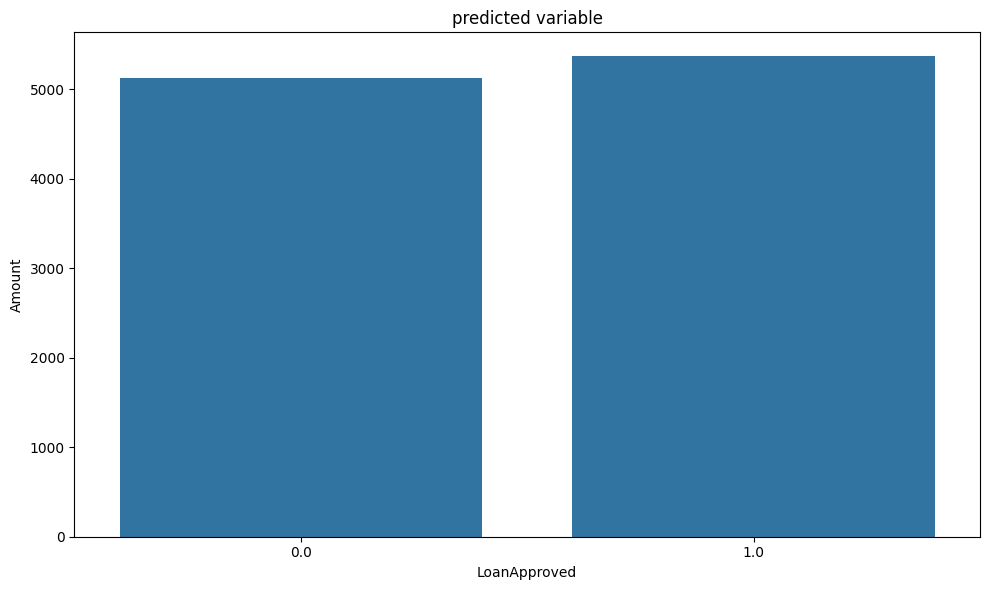

In [10]:
plt.figure(figsize=(10,6))
sns.countplot(x="LoanApproved",data=df)
plt.title("predicted variable")
plt.xlabel("LoanApproved")
plt.ylabel("Amount")
plt.tight_layout()
plt.show()


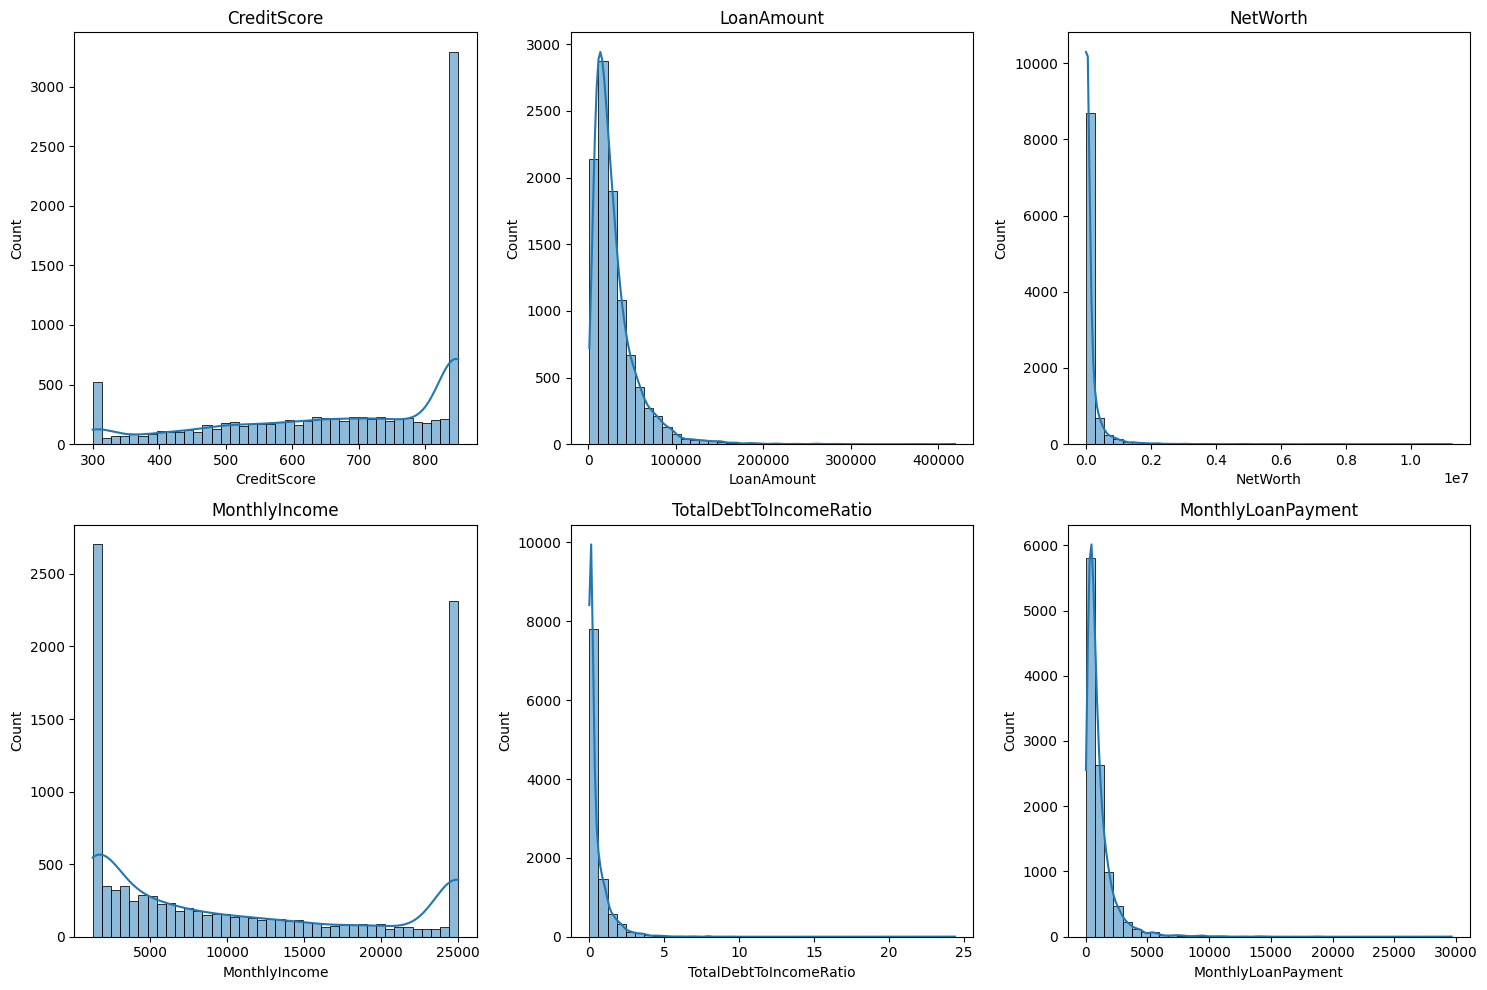

In [11]:
variabels = [
    "CreditScore",
    "LoanAmount",
    "NetWorth",
    "MonthlyIncome",
    "TotalDebtToIncomeRatio",
    "MonthlyLoanPayment"

]

fig, axes = plt.subplots(2,3,figsize=(15,10))
axes = axes.ravel()
for ax, col in zip(axes, variabels):
  sns.histplot(df[col],bins=40, kde=True, ax=ax)
  ax.set_title(col)

plt.tight_layout()
plt.show()

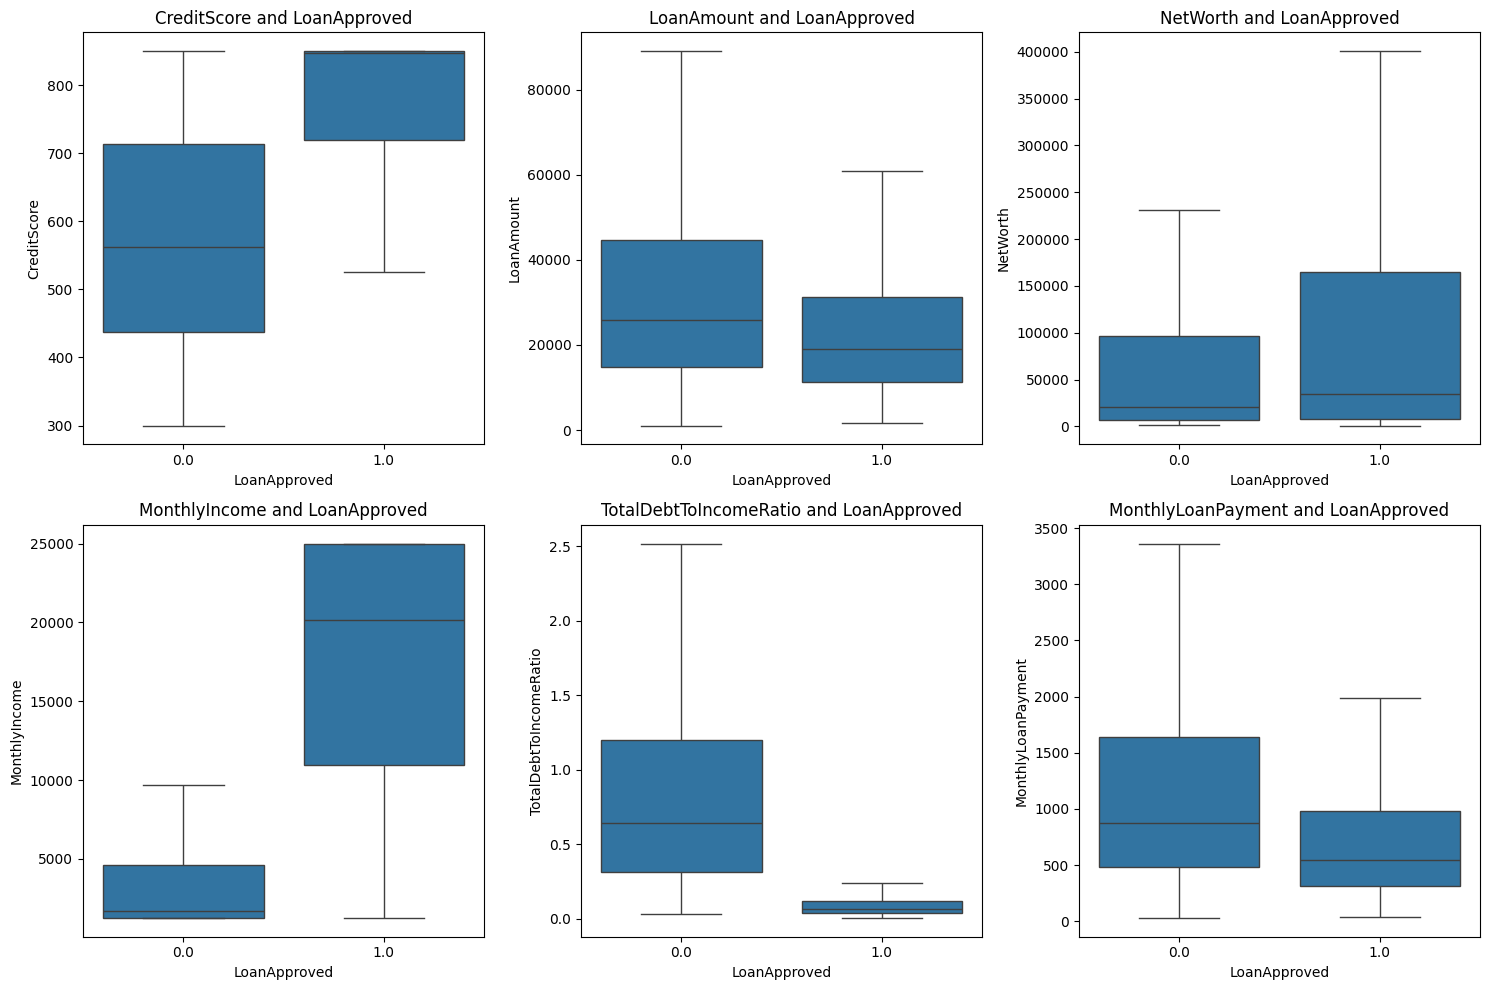

In [12]:
variables = [
    "CreditScore",
    "LoanAmount",
    "NetWorth",
    "MonthlyIncome",
    "TotalDebtToIncomeRatio",
    "MonthlyLoanPayment"
]

fig, axes = plt.subplots(2,3,figsize=(15,10))
axes = axes.ravel()
for ax, col in zip(axes, variables):
  sns.boxplot(x="LoanApproved",y=col,data=df, showfliers=False,ax=ax)
  ax.set_title(f"{col} and LoanApproved")

plt.tight_layout()
plt.show()

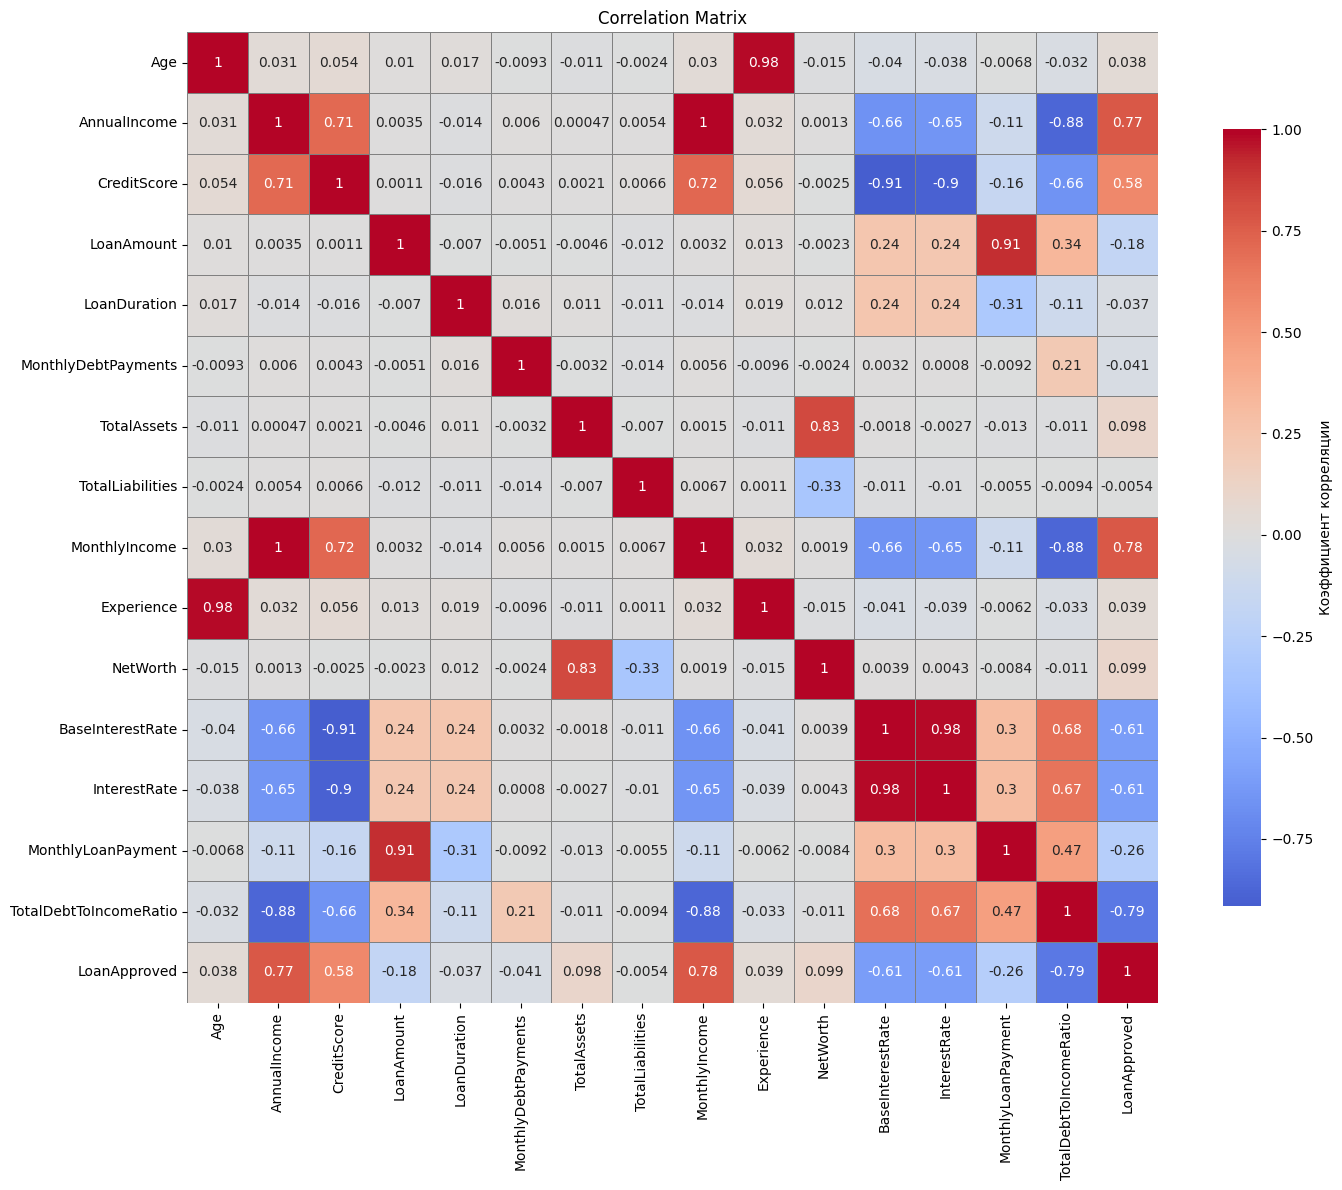

In [25]:
numeric_cols = df.select_dtypes(include=['number'])
col_cor = ['Age', 'AnnualIncome', 'CreditScore',
           'LoanAmount', 'LoanDuration',
           'MonthlyDebtPayments', 'TotalAssets',
           'TotalLiabilities', 'MonthlyIncome',
           'Experience', 'NetWorth',
           'BaseInterestRate', 'InterestRate',
           'MonthlyLoanPayment',
           'TotalDebtToIncomeRatio',
           'LoanApproved']

corr = numeric_cols[col_cor].corr(method='spearman')

plt.figure(figsize=(15, 12))
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            center=0,
            square=True,
            cbar_kws={'shrink': 0.8, 'label': 'Коэффициент корреляции'},
            linewidths=0.5,
            linecolor='gray')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [26]:
def norm(s):
    return (s - s.min()) / (s.max() - s.min())


def make_features(df_in):
    df = df_in.copy()

    # Даты
    df["ApplicationDate"] = pd.to_datetime(df["ApplicationDate"])
    min_date = pd.Timestamp("1970-01-01")
    df["AppYear"] = df["ApplicationDate"].dt.year
    df["AppMonth"] = df["ApplicationDate"].dt.month
    df["AppDays"] = (df["ApplicationDate"] - min_date).dt.days

    fill_cols = ["AnnualIncome", "TotalAssets", "TotalLiabilities", "NetWorth", "LoanDuration"]
    for c in fill_cols:
        if c in df.columns:
            df[c] = df[c].fillna(df[c].median())

    # Отношения
    df["Income_per_person"] = df["AnnualIncome"] / (df["NumberOfDependents"] + 1)
    df["Liabilities_to_Income"] = df["TotalLiabilities"] / (df["AnnualIncome"] + 10)
    df["Assets_to_Income"] = df["TotalAssets"] / (df["AnnualIncome"] + 10)
    df["Savings_to_Income"] = df["SavingsAccountBalance"] / (df["AnnualIncome"] + 10)

    for col in [
        "AnnualIncome",
        "LoanAmount",
        "TotalAssets",
        "TotalLiabilities",
        "NetWorth",
    ]:
        if col in df.columns:
            min_val = df[col].min()
            shift = abs(min_val) + 1.0 if min_val < 0 else 1.0
            df[f"log_{col}"] = np.log(df[col] + shift)

    # Взаимодействия
    df["Interest_Spread"] = df["InterestRate"] - df["BaseInterestRate"]
    df["CreditScore_sq"] = df["CreditScore"] ** 2

    df["Total_Payment_to_Income"] = (
        df["MonthlyDebtPayments"] + df["MonthlyLoanPayment"]
    ) / (df["MonthlyIncome"] + 10)
    df["Asset_Coverage"] = df["TotalAssets"] / (df["TotalLiabilities"] + 10)
    df["Negative_NetWorth"] = (df["NetWorth"] < 0).astype(int)
    df['Age_Bin'] = pd.qcut(df['Age'], q=5, labels=False, duplicates='drop')
    df['Income_Bin'] = pd.qcut(df['AnnualIncome'], q=5, labels=False, duplicates='drop')

    df['Dist_to_Bad'] = np.sqrt(
        norm(df['CreditScore']) ** 2 +
        norm(df['AnnualIncome']) ** 2 +
        (1 - norm(df['DebtToIncomeRatio'])) ** 2
    )

    df['Dist_to_Good'] = np.sqrt(
        (1 - norm(df['CreditScore'])) ** 2 +
        (1 - norm(df['AnnualIncome'])) ** 2 +
        norm(df['DebtToIncomeRatio']) ** 2
    )

    try:
        df['CreditScore_Bin'] = pd.qcut(df['CreditScore'], q=10, labels=False, duplicates='drop')
    except:
        pass

    df['LoanAmount_Bin'] = pd.qcut(df['LoanAmount'], q=10, labels=False, duplicates='drop')
    df['DTI_Bin'] = pd.qcut(df['DebtToIncomeRatio'], q=10, labels=False, duplicates='drop')

    if 'LoanDuration' in df.columns:
        df['Duration_Cat'] = df['LoanDuration'].round().astype(int).astype(str)

    try:
        df['NetWorth_Bin'] = pd.qcut(df['NetWorth'], q=5, labels=False, duplicates='drop')
    except:
        pass

    if 'ApplicationDate' in df.columns:
        df = df.drop(columns=['ApplicationDate'])

    return df

In [50]:
df_feat = make_features(df.drop(columns=["LoanApproved"]))
test_feat = make_features(test)

y = df["LoanApproved"].fillna(df["LoanApproved"].mode()[0]).astype(int).values

cat_cols = df_feat.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in df_feat.columns if c not in cat_cols]

numeric_tf = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
categorical_tf = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocess = ColumnTransformer(
    [
        ("num", numeric_tf, num_cols),
        ("cat", categorical_tf, cat_cols),
    ]
)

X_all = preprocess.fit_transform(df_feat)
X_test_all = preprocess.transform(test_feat)

if sp.issparse(X_all):
    X_all = X_all.tocsr()
    X_test_all = X_test_all.tocsr()

if len(X_all) != len(y):
    min_len = min(len(X_all), len(y))
    X_all = X_all[:min_len]
    y = y[:min_len]

X_train, X_val, y_train, y_val = train_test_split(
    X_all, y, test_size=0.2, stratify=y, random_state=42
)


def to_dense(mat):
    return mat.toarray() if sp.issparse(mat) else mat


X_train_dense = to_dense(X_train)
X_val_dense = to_dense(X_val)
X_all_dense = to_dense(X_all)
X_test_dense = to_dense(X_test_all)

In [52]:
def my_accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)


def my_precision(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    return tp / (tp + fp + 1e-12)


def my_recall(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tp / (tp + fn + 1e-12)


def my_f1(y_true, y_pred):
    p = my_precision(y_true, y_pred)
    r = my_recall(y_true, y_pred)
    return 2 * p * r / (p + r + 1e-12)


def my_roc_auc(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    order = np.argsort(-y_score)
    y_true = y_true[order]
    y_score = y_score[order]
    tps = np.cumsum(y_true)
    fps = np.cumsum(1 - y_true)
    tpr = tps / (tps[-1] + 1e-12)
    fpr = fps / (fps[-1] + 1e-12)
    return np.trapezoid(tpr, fpr)


def my_pr_auc(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    order = np.argsort(-y_score)
    y_true = y_true[order]
    tp = np.cumsum(y_true)
    fp = np.cumsum(1 - y_true)
    precision = tp / (tp + fp + 1e-12)
    recall = tp / (tp[-1] + 1e-12)
    return np.trapezoid(precision, recall)


def evaluate_metrics(y_true, y_pred, y_proba):
    return {
        "acc": my_accuracy(y_true, y_pred),
        "precision": my_precision(y_true, y_pred),
        "recall": my_recall(y_true, y_pred),
        "f1": my_f1(y_true, y_pred),
        "roc_auc": my_roc_auc(y_true, y_proba),
        "pr_auc": my_pr_auc(y_true, y_proba),
    }


def compare_with_sklearn(y_true, y_pred, y_proba):
    return {
        "acc_sk": accuracy_score(y_true, y_pred),
        "precision_sk": precision_score(y_true, y_pred),
        "recall_sk": recall_score(y_true, y_pred),
        "f1_sk": f1_score(y_true, y_pred),
        "roc_auc_sk": roc_auc_score(y_true, y_proba),
        "pr_auc_sk": average_precision_score(y_true, y_proba),
    }


In [48]:
class MyBaggingClassifier:
    def __init__(self, base_estimator=DecisionTreeClassifier, n_estimators=5, random_state=None):
        self.base_estimator = base_estimator
        self.n_estimators = n_estimators
        self.random_state = random_state
        self.estimators = []

    def fit(self, X, y):
        n_samples = X.shape[0]
        self.estimators_ = []

        X = np.array(X)
        y = np.array(y)

        for i in range(self.n_estimators):
            indices = np.random.choice(n_samples, size=n_samples, replace=True)
            X_bootstrap = X[indices]
            y_bootstrap = y[indices]

            estimator = clone(self.base_estimator)
            estimator.fit(X_bootstrap, y_bootstrap)
            self.estimators_.append(estimator)

        return self

    def predict(self, X):
        probas = self.predict_proba(X)[:, 1]
        return (probas > 0.5).astype(int)

    def predict_proba(self, X):
        probas = []
        for estimator in self.estimators_:
            probas.append(estimator.predict_proba(X)[:, 1])
        avg_proba = np.mean(probas, axis=0)
        return np.column_stack((1 - avg_proba, avg_proba))


In [53]:

base_tree = DecisionTreeClassifier(max_depth=8, min_samples_leaf=5, random_state=RANDOM_STATE)

my_bag = MyBaggingClassifier(
    base_estimator=base_tree, n_estimators=30, random_state=RANDOM_STATE
)
my_bag.fit(X_train_dense, y_train)
proba_my = my_bag.predict_proba(X_val_dense)[:, 1]
pred_my = (proba_my >= 0.5).astype(int)

sk_bag = BaggingClassifier(
    estimator=base_tree,
    n_estimators=30,
    max_samples=0.9,
    random_state=42,
    n_jobs=-1,
)
sk_bag.fit(X_train, y_train)
proba_sk = sk_bag.predict_proba(X_val)[:, 1]
pred_sk = sk_bag.predict(X_val)

print("=== MyBagging ===")
print(evaluate_metrics(y_val, pred_my, proba_my))
print(compare_with_sklearn(y_val, pred_my, proba_my))

print("\n=== sklearn BaggingClassifier ===")
print(evaluate_metrics(y_val, pred_sk, proba_sk))
print(compare_with_sklearn(y_val, pred_sk, proba_sk))

=== MyBagging ===
{'acc': np.float64(0.9246823956442831), 'precision': np.float64(0.9224999999999993), 'recall': np.float64(0.9381355932203382), 'f1': np.float64(0.9302521008398354), 'roc_auc': np.float64(0.9793589446504221), 'pr_auc': np.float64(0.9819535151367674)}
{'acc_sk': 0.9246823956442831, 'precision_sk': 0.9225, 'recall_sk': 0.938135593220339, 'f1_sk': 0.9302521008403362, 'roc_auc_sk': np.float64(0.9793610136387713), 'pr_auc_sk': np.float64(0.9828219850588688)}

=== sklearn BaggingClassifier ===
{'acc': np.float64(0.9246823956442831), 'precision': np.float64(0.9232053422370611), 'recall': np.float64(0.9372881355932197), 'f1': np.float64(0.9301934398649324), 'roc_auc': np.float64(0.9790957693326254), 'pr_auc': np.float64(0.9818011238450632)}
{'acc_sk': 0.9246823956442831, 'precision_sk': 0.9232053422370617, 'recall_sk': 0.9372881355932203, 'f1_sk': 0.9301934398654331, 'roc_auc_sk': np.float64(0.979095769332627), 'pr_auc_sk': np.float64(0.9826562063438493)}


In [61]:
class MyGradientBoostingClassifier:
    def __init__(self, n_estimators=100, init=None):
        self.n_estimators = n_estimators
        self.init = init
        self.models = []
        self.init_prediction = 0.0

    def _sigmoid(self, z):
        z = np.clip(z, -250, 250)
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        pos_count = y.sum()
        neg_count = len(y) - pos_count
        self.init_prediction = np.log((pos_count + 1e-6) / (neg_count + 1e-6))
        F = np.full(y.shape[0], self.init_prediction, dtype=np.float64)

        for _ in range(self.n_estimators):
            p = self._sigmoid(F)
            residuals = y - p
            if self.init is None:
              self.init = DecisionTreeRegressor(max_depth=3, random_state=42)
            model = type(self.init)(**self.init.get_params()) if hasattr(self.init, 'get_params') else self.init.__class__()
            model.fit(X, residuals)

            prediction_update = model.predict(X)
            F += 0.1 * prediction_update
            self.models.append(model)

        return self

    def predict_proba(self, X):
        F = np.full(X.shape[0], self.init_prediction, dtype=np.float64)
        for model in self.models:
            F += 0.1 * model.predict(X)
        proba_pos = self._sigmoid(F)
        proba_neg = 1 - proba_pos
        return np.column_stack([proba_neg, proba_pos])

    def predict(self, X):
        proba = self.predict_proba(X)
        return (proba[:, 1] >= 0.5).astype(int)

In [62]:
my_gb = MyGradientBoostingClassifier(n_estimators=120)
my_gb.fit(X_train_dense, y_train)
proba_my_gb = my_gb.predict_proba(X_val_dense)[:, 1]
pred_my_gb = (proba_my_gb >= 0.5).astype(int)

sk_gb = GradientBoostingClassifier(random_state=42)
sk_gb.fit(X_train, y_train)
proba_sk_gb = sk_gb.predict_proba(X_val)[:, 1]
pred_sk_gb = sk_gb.predict(X_val)

print("=== MyGradientBoosting ===")
print(evaluate_metrics(y_val, pred_my_gb, proba_my_gb))
print(compare_with_sklearn(y_val, pred_my_gb, proba_my_gb))

print("\n=== sklearn GradientBoostingClassifier ===")
print(evaluate_metrics(y_val, pred_sk_gb, proba_sk_gb))
print(compare_with_sklearn(y_val, pred_sk_gb, proba_sk_gb))


=== MyGradientBoosting ===
{'acc': np.float64(0.9233212341197822), 'precision': np.float64(0.918806959403479), 'recall': np.float64(0.9398305084745755), 'f1': np.float64(0.9291998324251383), 'roc_auc': np.float64(0.9772924390889813), 'pr_auc': np.float64(0.9801664895167692)}
{'acc_sk': 0.9233212341197822, 'precision_sk': 0.9188069594034797, 'recall_sk': 0.9398305084745763, 'f1_sk': 0.9291998324256389, 'roc_auc_sk': np.float64(0.9774211301641949), 'pr_auc_sk': np.float64(0.9810372527413304)}

=== sklearn GradientBoostingClassifier ===
{'acc': np.float64(0.9314882032667876), 'precision': np.float64(0.9291075896580476), 'recall': np.float64(0.9440677966101688), 'f1': np.float64(0.9365279529208949), 'roc_auc': np.float64(0.9835565082097442), 'pr_auc': np.float64(0.9856453290809655)}
{'acc_sk': 0.9314882032667876, 'precision_sk': 0.9291075896580484, 'recall_sk': 0.9440677966101695, 'f1_sk': 0.9365279529213956, 'roc_auc_sk': np.float64(0.9835565082097457), 'pr_auc_sk': np.float64(0.986508098

In [74]:
xgb_model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.1,
    max_depth=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric='auc'
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_val)
y_proba_xgb = xgb_model.predict_proba(X_val)[:, 1]

lgbm_model = LGBMClassifier(
    n_estimators=400,
    learning_rate=0.1,
    max_depth=-1,
    random_state=RANDOM_STATE,

    verbose=-1
)
lgbm_model.fit(X_train, y_train)
y_pred_lgbm = lgbm_model.predict(X_val)
y_proba_lgbm = lgbm_model.predict_proba(X_val)[:, 1]


cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    random_state=RANDOM_STATE,
    verbose=False,
)
cat_model.fit(X_train, y_train)
y_pred_cat = cat_model.predict(X_val)
y_proba_cat = cat_model.predict_proba(X_val)[:, 1]

print("My Gradient Boosting Classifier")
print(compare_with_sklearn(y_val, pred_my_gb, proba_my_gb))
print("Sklearn Gradient Boostring Classifier")
print(compare_with_sklearn(y_val, pred_sk_gb, proba_sk_gb))
print("XGBoost Classifier")
print(compare_with_sklearn(y_val, y_pred_xgb, y_proba_xgb))

print("LightGBM Classifier")

print(compare_with_sklearn(y_val, y_pred_lgbm, y_proba_lgbm))


print("CatBoost Classifier")

print(compare_with_sklearn(y_val, y_pred_cat, y_proba_cat))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


My Gradient Boosting Classifier
{'acc_sk': 0.9233212341197822, 'precision_sk': 0.9188069594034797, 'recall_sk': 0.9398305084745763, 'f1_sk': 0.9291998324256389, 'roc_auc_sk': np.float64(0.9774211301641949), 'pr_auc_sk': np.float64(0.9810372527413304)}
Sklearn Gradient Boostring Classifier
{'acc_sk': 0.9314882032667876, 'precision_sk': 0.9291075896580484, 'recall_sk': 0.9440677966101695, 'f1_sk': 0.9365279529213956, 'roc_auc_sk': np.float64(0.9835565082097457), 'pr_auc_sk': np.float64(0.9865080987172228)}
XGBoost Classifier
{'acc_sk': 0.9328493647912885, 'precision_sk': 0.9365482233502538, 'recall_sk': 0.938135593220339, 'f1_sk': 0.9373412362404742, 'roc_auc_sk': np.float64(0.9845843816207628), 'pr_auc_sk': np.float64(0.9873765131479489)}
LightGBM Classifier
{'acc_sk': 0.9360254083484574, 'precision_sk': 0.9383966244725739, 'recall_sk': 0.9423728813559322, 'f1_sk': 0.9403805496828752, 'roc_auc_sk': np.float64(0.9850635593220339), 'pr_auc_sk': np.float64(0.9877468752507776)}
CatBoost Cla

Алгоритм с лучшей метрикой данных: **CatBoost**

In [73]:
def objective(trial):
    max_depth = trial.suggest_int("max_depth", 3, 8)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.2, log=True)
    n_estimators = trial.suggest_int("n_estimators", 150, 500)
    subsample = trial.suggest_float("subsample", 0.6, 1.0)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0)

    model = XGBClassifier(
        max_depth=max_depth,
        learning_rate=learning_rate,
        n_estimators=n_estimators,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        objective="binary:logistic",
        eval_metric="auc",
        random_state=42,
        n_jobs=-1,
    )
    model.fit(X_train, y_train, verbose=False)
    proba = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, proba)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=25, timeout=600, show_progress_bar=False)
best_params = study.best_params
print("Лучшие параметры XGBoost:", best_params)

[I 2025-12-14 14:58:10,709] A new study created in memory with name: no-name-d29244c5-337a-4b4e-8ae8-2bbd922ea744
[I 2025-12-14 14:58:11,418] Trial 0 finished with value: 0.9812715174788136 and parameters: {'max_depth': 3, 'learning_rate': 0.02922820399240296, 'n_estimators': 176, 'subsample': 0.6100396807449863, 'colsample_bytree': 0.9634605997782678}. Best is trial 0 with value: 0.9812715174788136.
[I 2025-12-14 14:58:12,284] Trial 1 finished with value: 0.9847879700741525 and parameters: {'max_depth': 3, 'learning_rate': 0.07843430262840007, 'n_estimators': 245, 'subsample': 0.6772249162884199, 'colsample_bytree': 0.9379486309447089}. Best is trial 1 with value: 0.9847879700741525.
[I 2025-12-14 14:58:14,298] Trial 2 finished with value: 0.9845885195974575 and parameters: {'max_depth': 6, 'learning_rate': 0.05322665982320447, 'n_estimators': 253, 'subsample': 0.7421707766648349, 'colsample_bytree': 0.6417503112952262}. Best is trial 1 with value: 0.9847879700741525.
[I 2025-12-14 14

Лучшие параметры XGBoost: {'max_depth': 8, 'learning_rate': 0.02313789392872046, 'n_estimators': 499, 'subsample': 0.8090515598796932, 'colsample_bytree': 0.9250544981059301}


In [76]:

final_model = XGBClassifier(
    **best_params,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1,
)


final_model.fit(X_all, y)
final_proba = final_model.predict_proba(X_test_all)[:, 1]

submission = pd.DataFrame({"ID": test["ID"], "LoanApproved": final_proba})
submission.to_csv("submission.csv", index=False)
print(f"\nSubmission сохранен: {len(submission)} строк")
submission.head()


Submission сохранен: 5000 строк


,ID,LoanApproved
0,0,0.998492
1,1,0.001514
2,2,0.999519
3,3,0.998840
4,4,0.997160
